# Задача определения количества подразделений при наилучшей дислокации (LSCP)

В общем виде процесс решения задачи размещения можно представить следующим образом:

```{mermaid}
flowchart LR
  classDef style_optional  stroke-dasharray: 5 5
  classDef style_main  stroke:green, color:green

  load_data("**ЗАГРУЗКА
  ИСХОДНЫХ
  ДАННЫХ**"):::style_main

  data["Исходные
  данные"]
  settings["Настройки"]

  action("**ПРИМЕНЕНИЕ
  АЛГОРИТМА**"):::style_main

  model("**ИНИЦИАЛИЗАЦИЯ
  АЛГОРИТМА**"):::style_main

  result["Результат"]

  analyze("**АНАЛИЗ**"):::style_main
  save("**СОХРАНЕНИЕ**"):::style_main

  is_ok{"Результат
  приемлем"}

  fix("Изменение подхода"):::style_optional


  load_data --> data --> action
  model --> action
  settings --> model

  action --> result
  result --> analyze
  result -.-> save

  analyze --> is_ok

  is_ok -- ДА --> save
  is_ok -. НЕТ .-> fix

```

Решение задачи определения количества подразделений при наилучшей дислокации в **Генезис** осуществляется на основании двух подходов:

1. Решение за одну итерацию (единым алгоритмом)
2. Решение в несколько итераций решения задачи MCLP - на каждой итерации решается задача MCLP, после чего проверяется достигнута ли цель расчета. Если цель не достигнута, добавляется новая ПСЧ и выполняется следующая итерация MCLP.


В **Генезис** реализованы следующие алгоритмы решения задачи LSCP:

- Рекомендуемый:
  - `genesis.lscp.LSCP_ADD` -- Алгоритм жадного добавления (ADD) - *рекомендуемый*, реализующий первый подход
- Прочие:
  - `genesis.lscp.LSCP_Common` -- Общий модульный алгоритм, реализующий второй подход. 


Реализован также ряд дополнительных алгоритмов описываемых в разделе **Для разработчиков**.

## Подключение требуемых библиотек

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.036


## Рекомендуемый способ: Алгоритм жадного добавления

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки при размещении пожарного депо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

## Загрузка исходных данных

In [29]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Матрица прибытия

In [30]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 data_sample_size = 4000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


### Определение количества и оптимальной дислокации ПСЧ с целью достижения ИП-10 = 95%, без учета имеющихся подразделений.

Подразделений: 1  ИП-10: 30.36399488382008
Подразделений: 2  ИП-10: 53.71988914943509
Подразделений: 3  ИП-10: 62.02568748667662
Подразделений: 4  ИП-10: 67.84001279044979
Подразделений: 5  ИП-10: 74.61362182903432
Подразделений: 6  ИП-10: 79.2581539117459
Подразделений: 7  ИП-10: 84.70741846088254
Подразделений: 8  ИП-10: 87.32679599232573
Подразделений: 9  ИП-10: 89.3013216798124
Подразделений: 10  ИП-10: 91.36378170965679
Подразделений: 11  ИП-10: 93.43956512470689
Подразделений: 12  ИП-10: 95.03037731826903
ИТОГ:
Подразделений: 12  ИП-10: 95.03037731826903


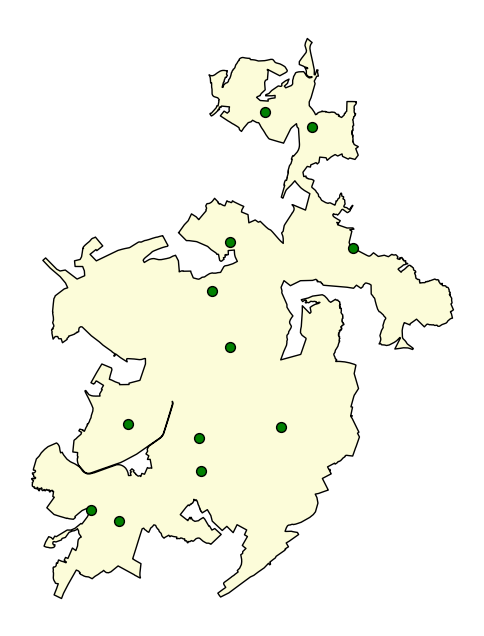

In [31]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка и инициализация алгоритма
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda value, **kwargs: value >= 95      # Расчет проводится для достижения ИП-10 = 95%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
    after_mclp_function = after_mclp,
)


# 3. Расчет
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
print('ИТОГ:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

### Определение количества и оптимальной дислокации ПСЧ с целью достижения ИП-10 = 98%, с учетом имеющихся подразделений.

Подразделений: 0  ИП-10: 72.44457471754423
Подразделений: 1  ИП-10: 81.3659134512897
Подразделений: 2  ИП-10: 86.8311660626732
Подразделений: 3  ИП-10: 90.93210402899169
Подразделений: 4  ИП-10: 95.01438925602217
Подразделений: 5  ИП-10: 96.98891494350885
Подразделений: 6  ИП-10: 97.57514389256022
Подразделений: 7  ИП-10: 98.3052654018333
ИТОГ:
Подразделений: 7  ИП-10: 98.3052654018333


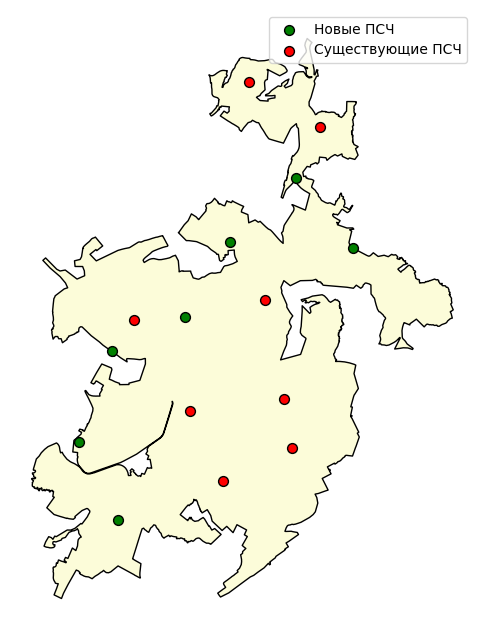

In [32]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda value, **kwargs: value >= 98      # Расчет проводится для достижения ИП-10 = 98%

## Функция выполняемая при добавлении новой ПСЧ
after_mclp = lambda best_metric, dynamic_nodes, **kwargs: print('Подразделений:', len(dynamic_nodes), ' ИП-10:', best_metric)

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
    after_mclp_function = after_mclp,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,
    )


# 4. Печать результатов
print('ИТОГ:')
print('Подразделений:', len(best_nodes), ' ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Новые ПСЧ')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

## Сохранение

In [ ]:
# Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

# Сохранение новых подразделений
## Создание нового набора данных
new_units = pd.DataFrame(best_nodes.items(), columns=['node', 'name'])
## Сопоставление с узлами ГДС
new_units = g_nodes.merge(new_units, left_index=True, right_on='node')
## Оставляем только нужные столбцы [имя, координаты, геометрия]
new_units = new_units[['name', 'x', 'y', 'geometry']]
## Сохранение в файл 'new_units.gpkg' и слой 'результат BLP'
new_units.to_file('data/kemerovo/new_units.gpkg', driver='GPKG', layer='результат MCLP')